In [3]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net
# , NetDiscovery
from diff_equations import grad, grinding_kinetics_2d

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme()
torch.manual_seed(42)

В этой ячейке нужно поменять данные на реальные

Text(0.5, 0, 'Time (s)')

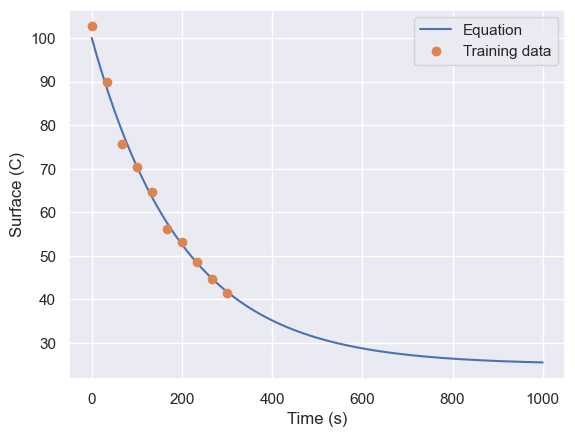

In [ ]:
np.random.seed(10)
# Ниже параметры неверные, но взяты для примера
Smax = 25
S0 = 100
k = 0.005
times = np.linspace(0, 1000, 1000)
eq = functools.partial(grinding_kinetics, Smax=Smax, S0=S0, k=k)
surfaces = eq(times)

# Make training data
t = np.linspace(0, 300, 10)
z = np.linspace(0, 10, 10)
S = eq(t) +  2 * np.random.randn(10)

plt.plot(times, surfaces)
plt.plot(t, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Surface (C)')
plt.xlabel('Time (s)')

Vanilla network (1,1 - это входная и выходная размерность)

Epoch 0/20000, loss: 4622.79
Epoch 2000/20000, loss: 2478.87
Epoch 4000/20000, loss: 1820.89
Epoch 6000/20000, loss: 241.73
Epoch 8000/20000, loss: 3.07
Epoch 10000/20000, loss: 2.40
Epoch 12000/20000, loss: 2.28
Epoch 14000/20000, loss: 2.18
Epoch 16000/20000, loss: 2.04
Epoch 18000/20000, loss: 1.91


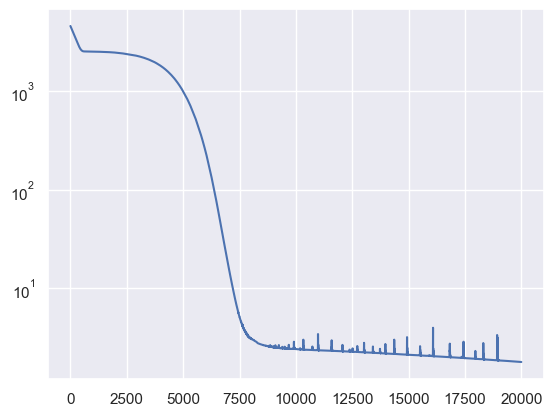

In [5]:
net = Net(1,1, loss2=None, epochs=20000, lr=1e-5).to(DEVICE)

losses = net.fit(t, S)

plt.plot(losses)
plt.yscale('log')

Та же сеть, но с регуляризацией L2

In [ ]:
def l2_reg(model: torch.nn.Module):
    # return torch.sum(sum([p.pow(2.) for p in model.parameters()]))

Epoch 0/20000, loss: 12291.20
Epoch 2000/20000, loss: 4397.21
Epoch 4000/20000, loss: 2647.45
Epoch 6000/20000, loss: 1668.27
Epoch 8000/20000, loss: 1197.68
Epoch 10000/20000, loss: 979.97
Epoch 12000/20000, loss: 858.40
Epoch 14000/20000, loss: 766.00
Epoch 16000/20000, loss: 683.16
Epoch 18000/20000, loss: 609.67


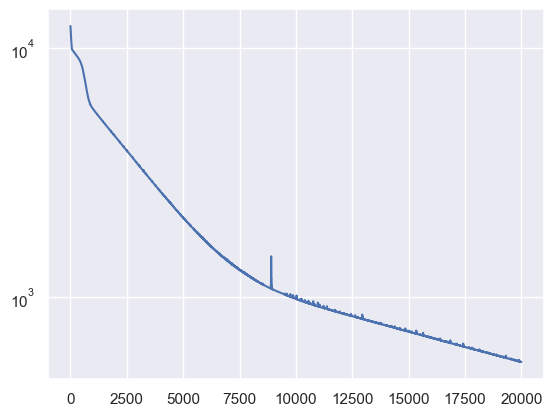

In [7]:
netreg = Net(1,1, loss2=l2_reg, epochs=20000, lr=1e-4, loss2_weight=1).to(DEVICE)

losses = netreg.fit(t, S)

plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Time (s)')

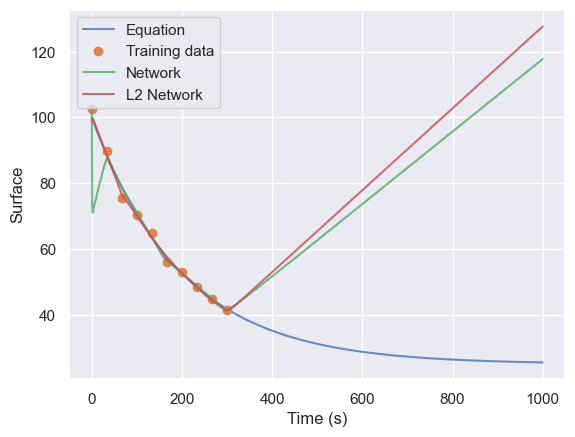

In [8]:
predsreg = netreg.predict(times)

preds = net.predict(times)
plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.plot(times, predsreg, alpha=0.8)

plt.legend(labels=['Equation','Training data', 'Network', 'L2 Network'])
plt.ylabel('Surface')
plt.xlabel('Time (s)')

## PINN

Loss с физическими ограничениями, но тут слишком простой пример, т.к. дифф.уравнение полностью описывает данные и мы можем посчитать его вручную

In [4]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    ode = dS - k*(Smax - surfaces)
    
    return torch.mean(ode**2)

Epoch 0/20000, loss: 4713.90
Epoch 2000/20000, loss: 2524.88
Epoch 4000/20000, loss: 2282.30
Epoch 6000/20000, loss: 809.36
Epoch 8000/20000, loss: 30.06
Epoch 10000/20000, loss: 0.83
Epoch 12000/20000, loss: 0.44
Epoch 14000/20000, loss: 0.47
Epoch 16000/20000, loss: 0.37
Epoch 18000/20000, loss: 0.32


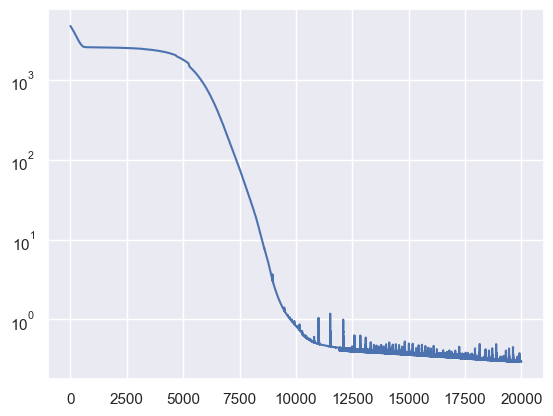

In [5]:
net = Net(1,1, loss2=physics_loss, epochs=20000, loss2_weight=1, lr=1e-5).to(DEVICE)

losses = net.fit(t, S)
plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Время (s)')

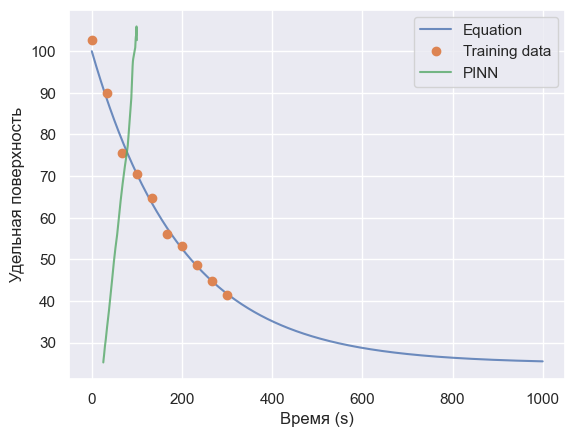

In [6]:
preds = net.predict(times)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(surfaces, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность')
plt.xlabel('Время (s)')

## PINN с неизвестной k:

In [ ]:
# import importlib
# import sys

<module 'network' from 'c:\\Users\\anna\\Desktop\\itmo\\nir\\PINN\\src\\network.py'>

In [ ]:
# importlib.reload(sys.modules['network'])
from network import PINN

для случая, когда не знаем k, v_m

In [ ]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    pde = model.k * (Smax - surfaces) - dS
    
    return torch.mean(pde**2)

Epoch 0/20000, loss: 4622.79
Epoch 2000/20000, loss: 2538.62
Epoch 4000/20000, loss: 2482.65
Epoch 6000/20000, loss: 2328.99
Epoch 8000/20000, loss: 1880.12
Epoch 10000/20000, loss: 776.08
Epoch 12000/20000, loss: 141.79
Epoch 14000/20000, loss: 6.53
Epoch 16000/20000, loss: 1.04
Epoch 18000/20000, loss: 0.70


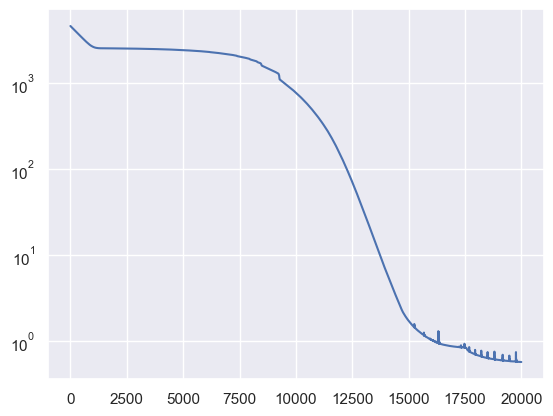

In [ ]:
pinn = PINN(1, 1, loss2=physics_loss, loss2_weight=1, epochs=20000, lr= 5e-6).to(DEVICE)


losses = pinn.fit(t, S)
plt.plot(losses)
plt.yscale('log')

Parameter containing:
tensor([0.0052], requires_grad=True)


Text(0.5, 0, 'Время (s)')

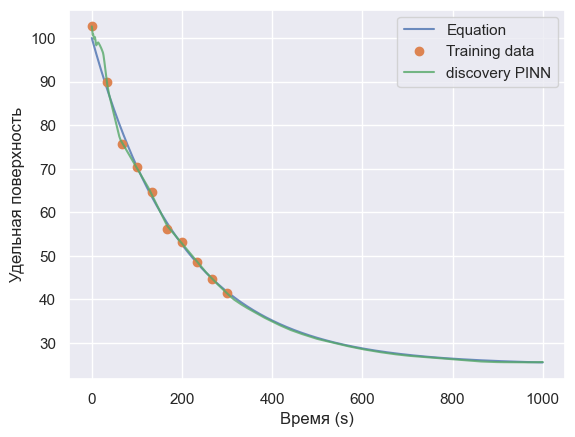

In [ ]:
preds = pinn.predict(times)
print(pinn.k)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность')
plt.xlabel('Время (s)')

## PINN итоговая

In [1]:
from network import PINN

In [4]:
def physics_loss(model: torch.nn.Module, L_m=10.0, v_m=1.0):
    # Создаем сетку точек (z, t) внутри области определения
    z = torch.linspace(0, L_m, steps=100, requires_grad=True).view(-1, 1).to(DEVICE)
    t = torch.linspace(0, 1000, steps=100, requires_grad=True).view(-1, 1).to(DEVICE)
    
    # Создаем сетку (все комбинации z и t)
    Z, T = torch.meshgrid(z.squeeze(), t.squeeze(), indexing='ij')
    Z = Z.reshape(-1, 1)
    T = T.reshape(-1, 1)
    
    inputs = torch.cat([Z, T], dim=1).requires_grad_(True).to(DEVICE)
    
    # Предсказание модели S(z,t)
    S = model(inputs)
    
    # Вычисляем градиенты S по входам (z, t)
    dS_dz = grad(S, inputs)[0]
    dS_dt = grad(S, inputs)[0]
    
    # Уравнение (33): dS/dt + (F_m/M) * dS/dz = k * (Smax - S)
    # Для простоты предположим F_m/M = v_m = const
    pde = dS_dt + model.v_m * dS_dz - model.k * (model.Smax - S)
    
    return torch.mean(pde**2)

In [7]:
Smax = 500
S0 = 100
k = 0.005
v_m = 0.05
eq = functools.partial(grinding_kinetics_2d, Smax=Smax, S0=S0, k=k)

# Make training data
t = np.linspace(0, 300, 10)
z = np.linspace(0, 10, 10)
S = eq(z_points=z, t_points=t) +  2 * np.random.randn(10)

In [ ]:
# plt.plot(t, s)
plt.plot(t, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Surface (C)')
plt.xlabel('Time (s)')

ValueError: x and y must have same first dimension, but have shapes (10,) and (2, 10, 10)

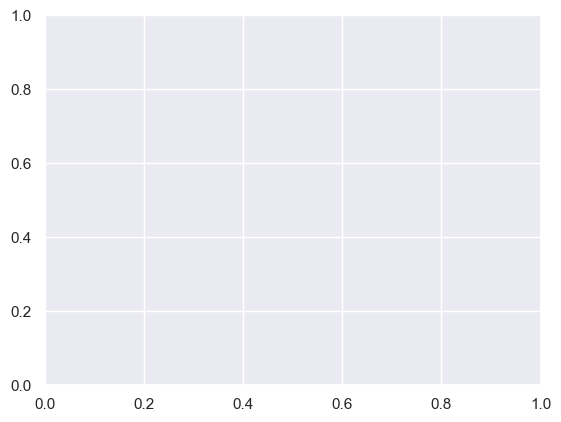

In [9]:
# plt.plot(times, surfaces)
plt.plot(z, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Surface (C)')
plt.xlabel('Расстояние от начала мельницы, м')

In [17]:
pinn = PINN(2, 1, loss2=physics_loss, loss2_weight=1, epochs=20000, lr= 5e-6).to(DEVICE)

args = np.column_stack((t,z))

losses = pinn.fit(args, S)
plt.plot(losses)
plt.yscale('log')

c:\Users\User\Desktop\NIR\PINN\venv\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([10, 1])) that is different to the input size (torch.Size([2, 100])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (2) must match the size of tensor b (10) at non-singleton dimension 0

In [13]:
# запусти этот код сначала должно быть 10,2

args = np.column_stack((t,z))
args.shape

(10, 2)